In [1]:
import tensorflow as tf
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


In [2]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time
from IPython import display

# Install tensorflow-datasets if not available
try:
    import tensorflow_datasets as tfds
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'tensorflow-datasets', '-q'])
    import tensorflow_datasets as tfds

print('All imports successful.')

All imports successful.


In [ ]:
# Load SVHN dataset
ds_train, ds_info = tfds.load(
    'svhn_cropped',
    split='train',
    as_supervised=False,  # returns dict with 'image' and 'label'
    with_info=True
)

print('Dataset info:')
print(f'  Training examples: {ds_info.splits["train"].num_examples}')
print(f'  Image shape: {ds_info.features["image"].shape}')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.J145EA_3.1.0/svhn_cropped-train.tfrecord*...:   0%…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.J145EA_3.1.0/svhn_cropped-test.tfrecord*...:   0%|…

Generating extra examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.J145EA_3.1.0/svhn_cropped-extra.tfrecord*...:   0%…

Dataset svhn_cropped downloaded and prepared to /root/tensorflow_datasets/svhn_cropped/3.1.0. Subsequent calls will reuse this data.
Dataset info:
  Training examples: 73257
  Image shape: (32, 32, 3)


In [ ]:
# Hyperparameters
IMAGE_SHAPE = (32, 32, 3)
BUFFER_SIZE = 60000
BATCH_SIZE = 128

def preprocess(sample):
    """Normalize images from [0,255] to [-1, 1] and cast to float32."""
    image = tf.cast(sample['image'], tf.float32)
    image = (image - 127.5) / 127.5  # Normalize to [-1, 1]
    return image

train_dataset = (
    ds_train
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print('Training dataset pipeline built successfully.')

Training dataset pipeline built successfully.


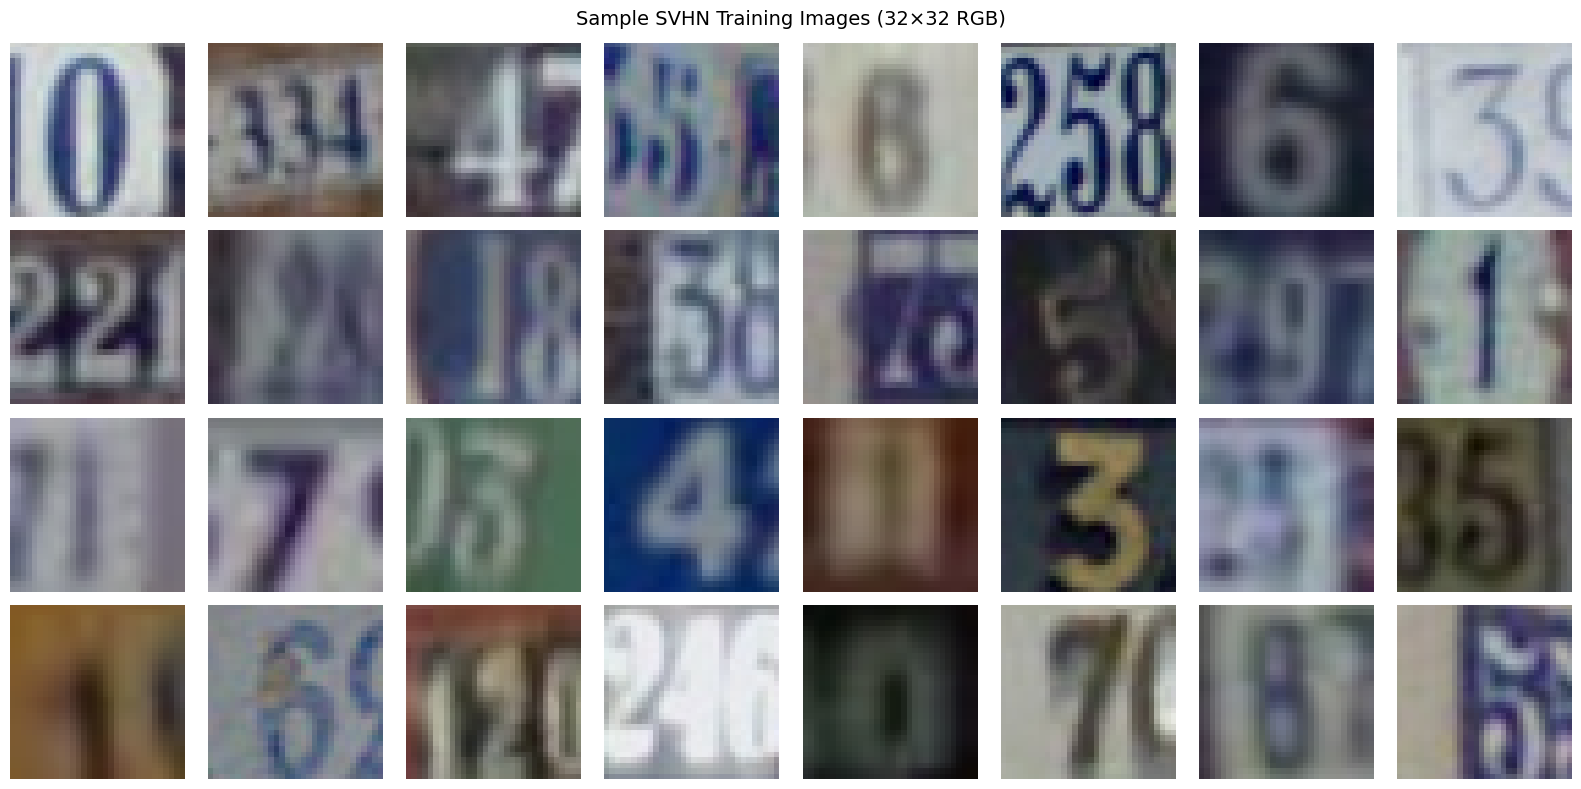

Image batch shape: (128, 32, 32, 3)


In [ ]:
# Visualize sample SVHN images
sample_batch = next(iter(train_dataset))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    img = (sample_batch[i].numpy() + 1.0) / 2.0
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Sample SVHN Training Images (32×32 RGB)', fontsize=14)
plt.tight_layout()
plt.savefig('svhn_sample_images.png', dpi=100)
plt.show()
print(f'Image batch shape: {sample_batch.shape}')

In [ ]:
def make_generator_model():
    """
    Generator: 100-dim noise to 32x32x3 RGB image (for SVHN).
    """
    model = tf.keras.Sequential(name='Generator')

    # Project noise into 4x4 spatial map
    model.add(layers.Dense(4 * 4 * 512, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((4, 4, 512)))
    assert model.output_shape == (None, 4, 4, 512)

    # 4x4 to 8x8
    model.add(layers.Conv2DTranspose(256, (5, 5), strides=(2, 2),
                                     padding='same', use_bias=False))
    assert model.output_shape == (None, 8, 8, 256)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 8x8 to 16x16
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2),
                                     padding='same', use_bias=False))
    assert model.output_shape == (None, 16, 16, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 16x16 to 32x32
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2),
                                     padding='same', use_bias=False))
    assert model.output_shape == (None, 32, 32, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 32x32 to 32x32 with 3 channels (RGB)
    model.add(layers.Conv2DTranspose(3, (5, 5), strides=(1, 1),
                                     padding='same', use_bias=False,
                                     activation='tanh'))
    assert model.output_shape == (None, 32, 32, 3)

    return model

generator = make_generator_model()
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8192)           │       819,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8192)           │        32,768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │     3,276,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 32, 3)      │         4,800 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,159,360 (19.68 MB)

 Trainable params: 5,142,080 (19.62 MB)

 Non-trainable params: 17,280 (67.50 KB)

Generated image shape: (1, 32, 32, 3)


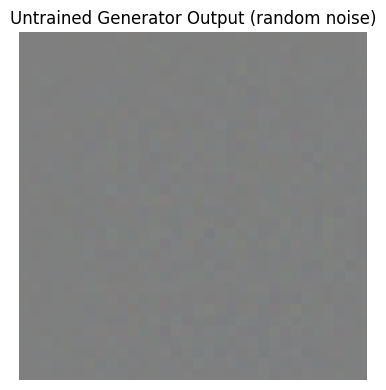

In [7]:
# Test generator with random noise
noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

print(f'Generated image shape: {generated_image.shape}')  # Should be (1, 32, 32, 3)

# Visualize untrained generator output (random noise)
plt.figure(figsize=(4, 4))
img = (generated_image[0].numpy() + 1.0) / 2.0  # Denormalize
plt.imshow(img)
plt.title('Untrained Generator Output (random noise)')
plt.axis('off')
plt.tight_layout()
plt.savefig('untrained_generator_output.png', dpi=100)
plt.show()

In [ ]:
def make_discriminator_model():
    """
    Discriminator: 32x32x3 RGB image to real/fake scalar.
    """
    model = tf.keras.Sequential(name='Discriminator')

    # 32x32 to 16x16
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                            input_shape=(32, 32, 3)))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    # 16x16 to 8x8
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    # 8x8 to 4x4
    model.add(layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    # 4x4 to 2x2
    model.add(layers.Conv2D(512, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))   # raw logit; loss handles sigmoid

    return model

discriminator = make_discriminator_model()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 512)      │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,308,609 (16.44 MB)

 Trainable params: 4,308,609 (16.44 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Test discriminator on the generated image
decision = discriminator(generated_image, training=False)
print(f'Discriminator decision on fake image: {decision.numpy()}')
print('  (Positive = predicted real, Negative = predicted fake)')

Discriminator decision on fake image: [[-1.0872682e-06]]
  (Positive = predicted real, Negative = predicted fake)


In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output) * 0.9, real_output)  # label smoothing
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer     = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)

print('Loss functions and optimizers defined.')


Loss functions and optimizers defined.


In [11]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
checkpoint = tf.train.Checkpoint(
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    generator=generator,
    discriminator=discriminator
)

print(f'Checkpoint directory: {checkpoint_dir}')

Checkpoint directory: ./training_checkpoints


In [ ]:
EPOCHS = 25
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])

print(f'Training configuration:')
print(f'  Epochs: {EPOCHS}')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  Noise dimension: {noise_dim}')
print(f'  Examples per preview: {num_examples_to_generate}')

Training configuration:
  Epochs: 25
  Batch size: 128
  Noise dimension: 100
  Examples per preview: 16


In [ ]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss, discriminator.trainable_variables)
    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables))

    noise2 = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as disc_tape2:
        generated_images2 = generator(noise2, training=True)
        real_output2  = discriminator(images, training=True)
        fake_output2  = discriminator(generated_images2, training=True)
        disc_loss2 = discriminator_loss(real_output2, fake_output2)

    gradients_of_discriminator2 = disc_tape2.gradient(
        disc_loss2, discriminator.trainable_variables)
    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator2, discriminator.trainable_variables))

    noise3 = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape:
        generated_images3 = generator(noise3, training=True)
        fake_output3 = discriminator(generated_images3, training=True)
        gen_loss = generator_loss(fake_output3)

    gradients_of_generator = gen_tape.gradient(
        gen_loss, generator.trainable_variables)
    generator_optimizer.apply_gradients(
        zip(gradients_of_generator, generator.trainable_variables))

    return gen_loss, disc_loss

print('train_step() compiled.')


train_step() compiled.


In [ ]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(8, 8))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        img = (predictions[i].numpy() + 1.0) / 2.0
        img = np.clip(img, 0, 1)  # Clip to valid range
        plt.imshow(img)
        plt.axis('off')

    plt.suptitle(f'SVHN DCGAN — Epoch {epoch:03d}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'image_at_epoch_{epoch:04d}.png', dpi=80)
    plt.show()

print('generate_and_save_images() defined.')

generate_and_save_images() defined.


In [15]:
def train(dataset, epochs):
    gen_losses = []
    disc_losses = []

    for epoch in range(epochs):
        start = time.time()
        epoch_gen_loss = []
        epoch_disc_loss = []

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
            epoch_gen_loss.append(g_loss.numpy())
            epoch_disc_loss.append(d_loss.numpy())

        # Generate preview at end of each epoch
        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed)

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        avg_gen = np.mean(epoch_gen_loss)
        avg_disc = np.mean(epoch_disc_loss)
        gen_losses.append(avg_gen)
        disc_losses.append(avg_disc)

        elapsed = time.time() - start
        print(f'Epoch {epoch+1:3d}/{epochs} | '
              f'Gen Loss: {avg_gen:.4f} | '
              f'Disc Loss: {avg_disc:.4f} | '
              f'Time: {elapsed:.1f}s')

    # Final image after all epochs
    display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed)

    return gen_losses, disc_losses

print('train() function defined.')

train() function defined.


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU(s) available: {len(gpus)}')
if gpus:
    for gpu in gpus:
        print(f'  {gpu}')
else:
    print('  No GPU detected — training will be slow on CPU!')
    print('  Consider using Google Colab with GPU runtime.')

GPU(s) available: 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


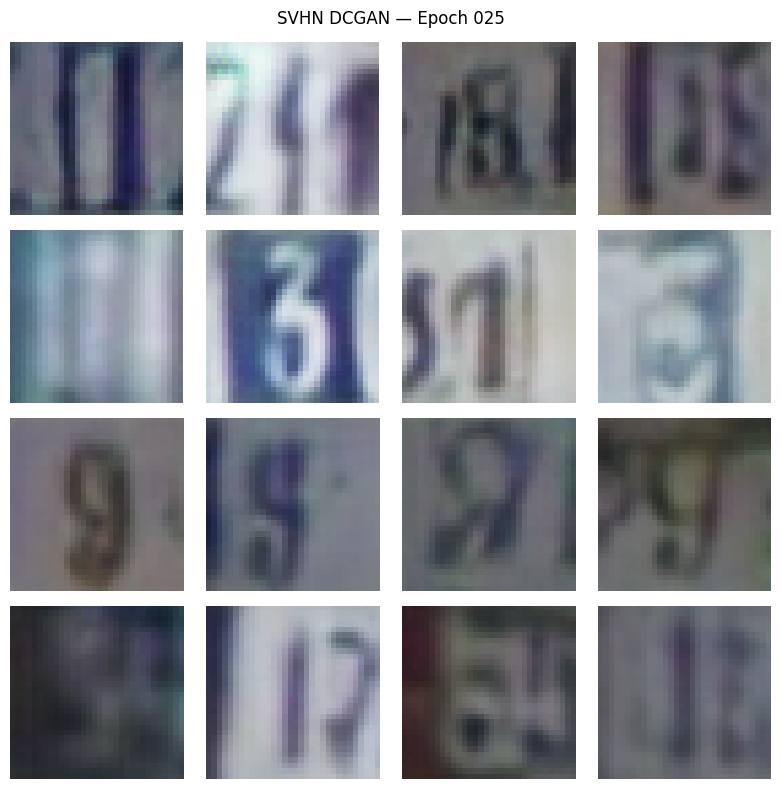

CPU times: user 51min 38s, sys: 2min 54s, total: 54min 33s
Wall time: 1h 23min 26s


In [ ]:
%%time
gen_losses, disc_losses = train(train_dataset, EPOCHS)

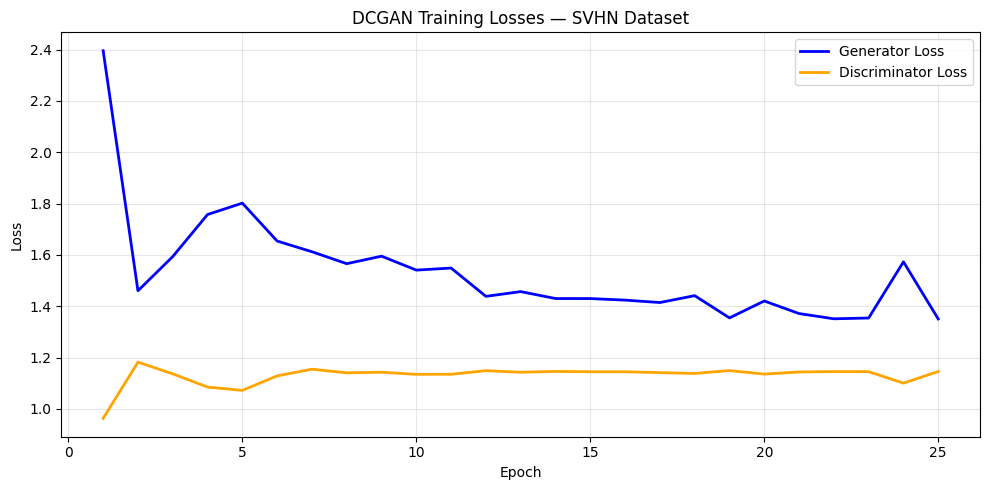

Final Generator Loss:     1.3502
Final Discriminator Loss: 1.1455


In [18]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), gen_losses,  label='Generator Loss',     color='blue',   linewidth=2)
plt.plot(range(1, EPOCHS + 1), disc_losses, label='Discriminator Loss',  color='orange', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DCGAN Training Losses — SVHN Dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_losses.png', dpi=100)
plt.show()

print(f'Final Generator Loss:     {gen_losses[-1]:.4f}')
print(f'Final Discriminator Loss: {disc_losses[-1]:.4f}')

In [19]:
# Restore latest checkpoint
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))
print('Latest checkpoint restored.')

Latest checkpoint restored.


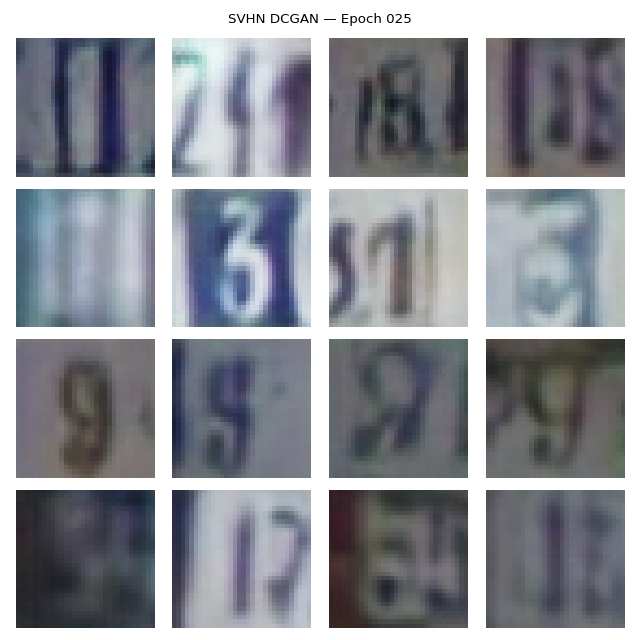

In [20]:
# Display the last saved epoch image
def display_image(epoch_no):
    return PIL.Image.open(f'image_at_epoch_{epoch_no:04d}.png')

display_image(EPOCHS)

GIF saved to: dcgan_svhn.gif


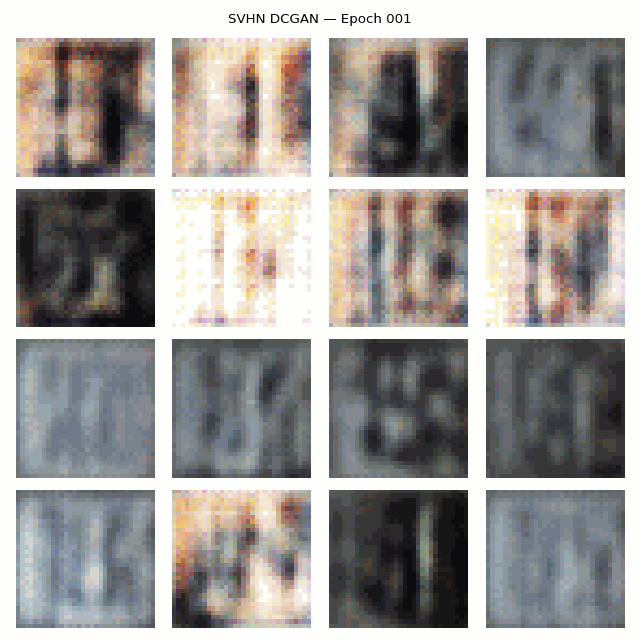

In [ ]:
anim_file = 'dcgan_svhn.gif'

with imageio.get_writer(anim_file, mode='I', duration=0.2) as writer:
    filenames = glob.glob('image_at_epoch_*.png')
    filenames = sorted(filenames)
    for filename in filenames:
        image = imageio.v2.imread(filename)
        writer.append_data(image)
    # Add the last frame again to pause
    image = imageio.v2.imread(filename)
    writer.append_data(image)

print(f'GIF saved to: {anim_file}')

import IPython
IPython.display.Image(filename=anim_file)

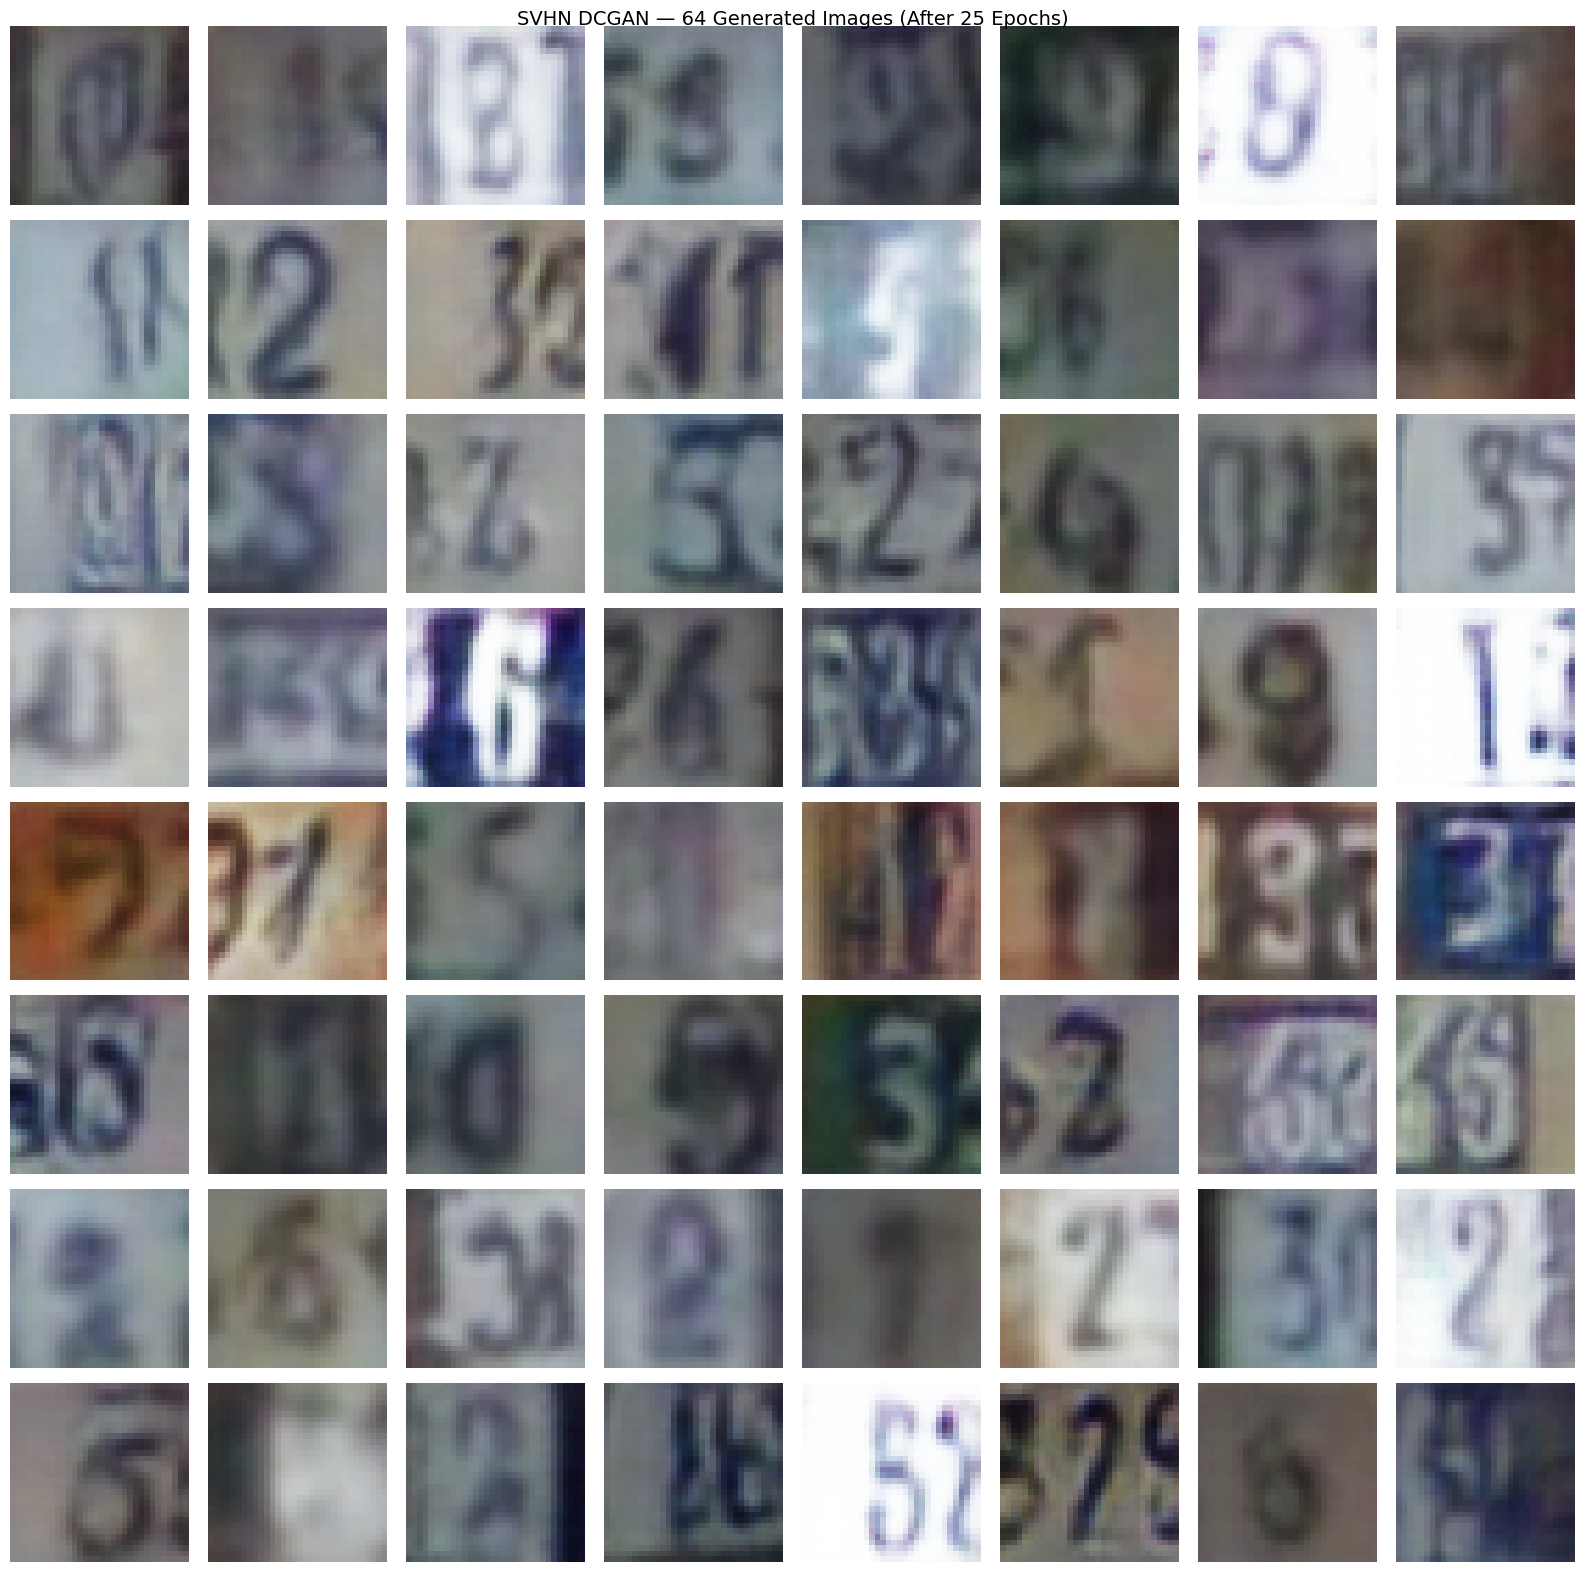

In [22]:
# Generate a fresh batch of 64 images
new_noise = tf.random.normal([64, noise_dim])
new_images = generator(new_noise, training=False)

fig, axes = plt.subplots(8, 8, figsize=(16, 16))
for i, ax in enumerate(axes.flatten()):
    img = (new_images[i].numpy() + 1.0) / 2.0
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis('off')

plt.suptitle(f'SVHN DCGAN — 64 Generated Images (After {EPOCHS} Epochs)', fontsize=14)
plt.tight_layout()
plt.savefig('final_generated_images.png', dpi=100)
plt.show()